In [46]:
# Import requried  Labs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
#Load DataSet
df = pd.read_csv("../../ML DATASET/census_income.csv")



In [48]:
#About DataSet
# Dataset contains information  abot individuals for predicting their annual income 
# data has 32561 row and 15 columns

#About EDA 
# while doing EDA i encountered with null , duplicate and outliers 
# i cleaned the data by handling null,duplicate and outlier for specific columns 
# i applied labelencoder for object dtypes for using them into train and testing for models 
# i splitted dataset in traing and testion (80% for train and 20% for testing)
# build the models - logisticregreesion , decisiontree, randomforest, adaboost
# visulized plot of thier accury score 

# About Result 
#i applied this dataset on LogisticRegression, RandomForestClassifier, DecisionTreeClassifier, AdaBoostClassifier , and AdaBoostClassifier with n_estimators(100)
# but all of model performed well where LogisticRegression with 0.79 accuracy score , DecisionTree 0.80, RandomForest 0.85 AdaBoost with 0.85 and AdaBoost Model 2 0.85
#so i can say RandomForest , AdaBoost performs slighty better than LogisticsRegression and DecisionTree'''


In [49]:
# CHECK NUMBER ROWS AND COLUMN
df.shape

(32561, 15)

In [50]:
# CHECK COLUMN NAME 
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='str')

In [51]:
# DISPLAYING FIRST FIVE ROWS 
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [52]:
# CHECK DATA TYPES AND MISSING VALUES 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  annual_income   32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [53]:
# STATICAL SUMMERY OF NUMRICAL COL 
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [54]:
# CHECK THE NUMBER OF DUPLICATE ROWS 
df.duplicated().sum()


np.int64(24)

In [55]:
# REMOVE  DUPLICATE ROWS
df.drop_duplicates(inplace=True)

In [56]:

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
annual_income     0
dtype: int64

In [57]:
# Replace '?' and blank spaces with NaN
df.replace(["?", " "], np.nan, inplace=True)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [58]:
# CHECK  FOR MISSING VALUES IN EACH COLUMN  
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     582
annual_income        0
dtype: int64

In [59]:
# CHECK  TOTAL NUMBER OF NULL VALUES 
df.isnull().sum().sum()

np.int64(4261)

In [60]:
# FILL MISSING CATEGORICAL VALUES WITH MOST FREQUENT VALUE
for i in df.select_dtypes(include = "object").columns:
    df[i]=df[i].fillna(df[i].mode()[0])

C:\Users\bhuse\AppData\Local\Temp\ipykernel_5748\2987041196.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in df.select_dtypes(include = "object").columns:


In [61]:
# VERYFYING THAT MISSING VALUES HAVE BEEN  HANDLED 
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
annual_income     0
dtype: int64

In [62]:
# check target class distribution 
df['annual_income'].value_counts()

annual_income
<=50K    24698
>50K      7839
Name: count, dtype: int64

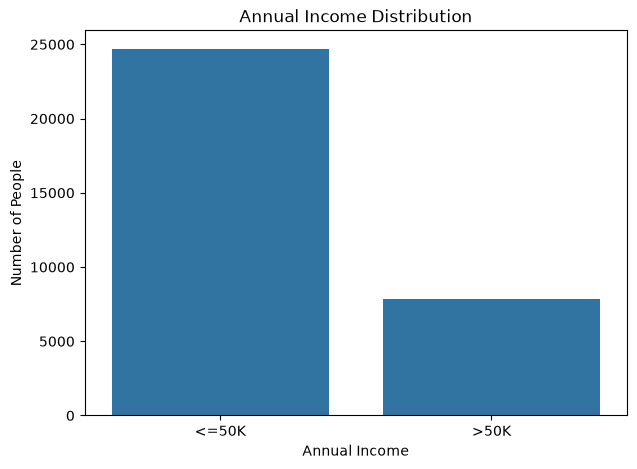

In [63]:
plt.figure(figsize =(7,5))
sns.countplot(data=df, x ='annual_income')


plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of People")

plt.show()

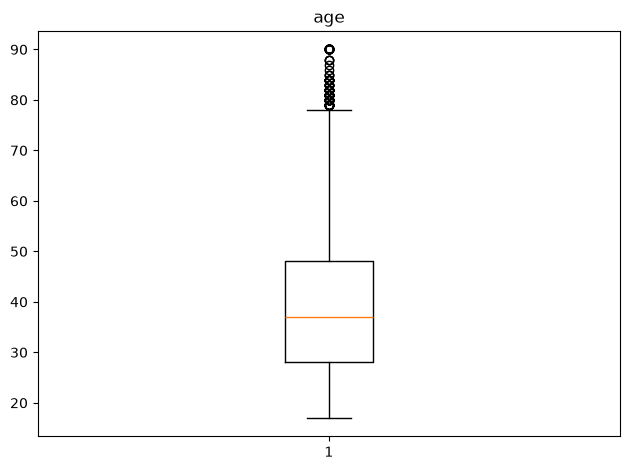

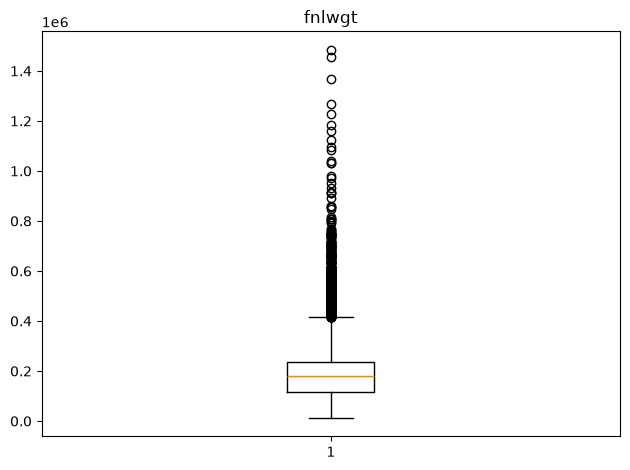

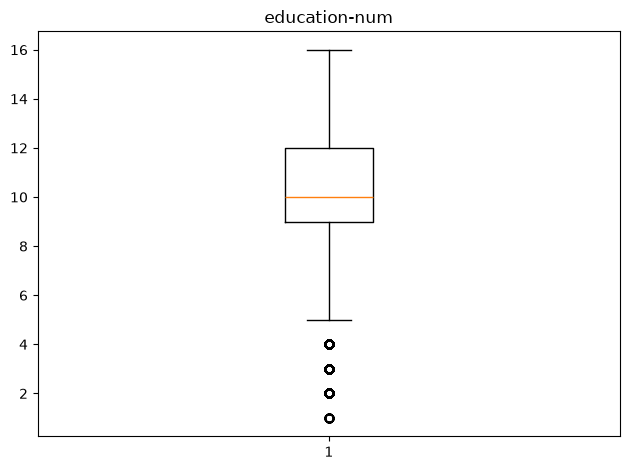

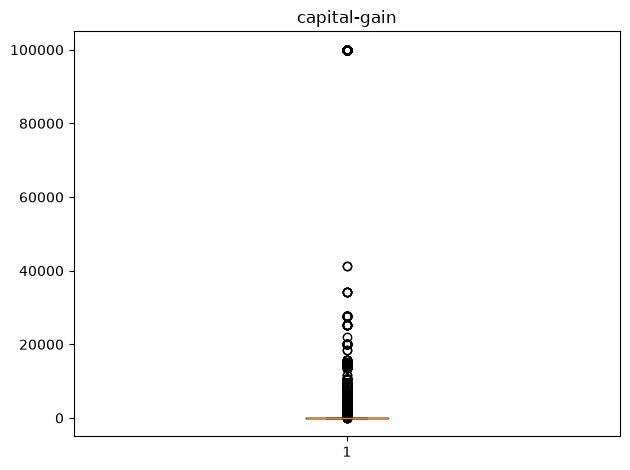

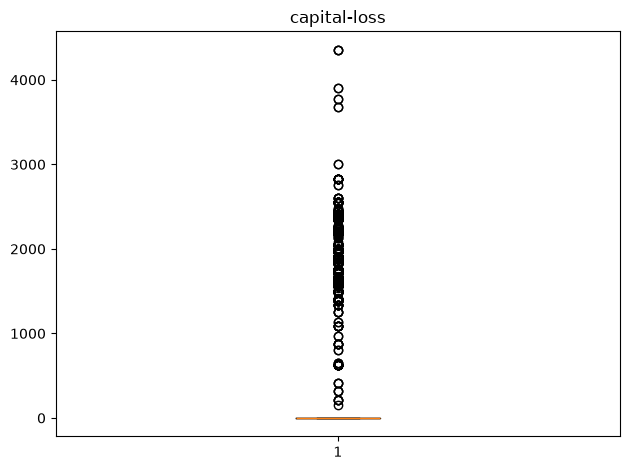

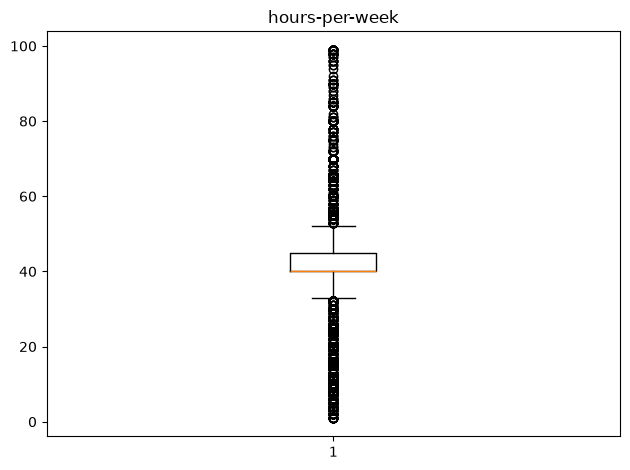

In [64]:
# DISPLAY BOXPLOT
num_col = df.select_dtypes(include = "number")

for  col in num_col:
     plt.boxplot(df[col])
     plt.title(col)
     plt.tight_layout()
     plt.show()


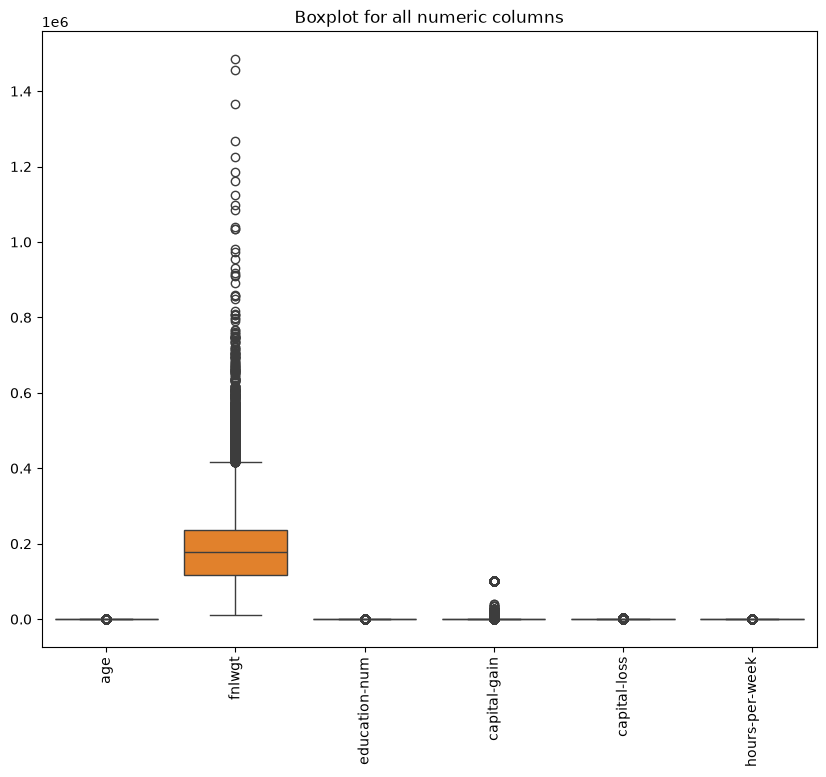

In [65]:
# INSPECTING OUTLIER FOR COLUMNS 
plt.figure(figsize=(10,8))
sns.boxplot(data= df.select_dtypes(include = 'number'))
plt.xticks(rotation = 90)
plt.title('Boxplot for all numeric columns')
plt.show()

In [66]:
# APPLYING IQR FOR THIS COLUMN THEY HAVE MUCH MORE GENIUNE OUTLIERS 
col = ['fnlwgt','hours-per-week']

In [67]:
#APPLYING IQR METHOD TO REDUCE/REMOVE OUTLIERS 
for i in col:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3-Q1
  LB = Q1-1.5*IQR
  UB = Q3+1.5*IQR
  df = df[(df[i]>=LB) & (df[i]<=UB)]

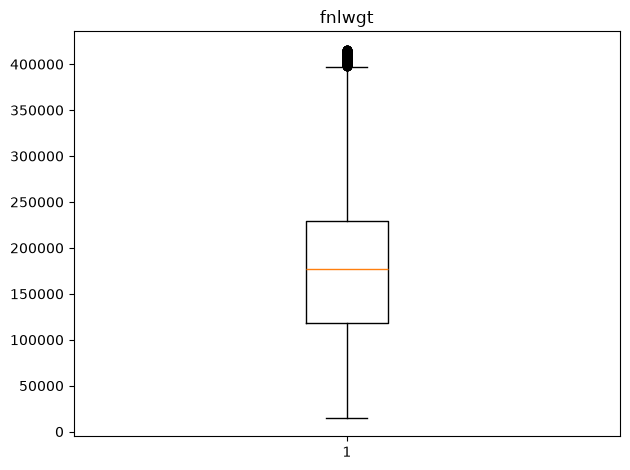

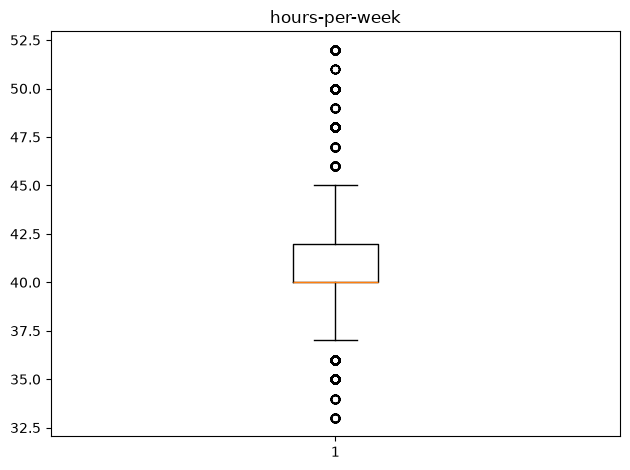

In [68]:
# AFTER OUTLIER FILTERING 
for i in col:
  plt.boxplot(df[i])
  plt.title(i)
  plt.tight_layout()
  plt.show()

In [69]:
# Separate independent variables and target variable

x = df.drop("annual_income", axis=1)

y = df["annual_income"]

print(x.head())

print(y.head())

   age  workclass  fnlwgt  education  education-num      marital-status  \
0   39  State-gov   77516  Bachelors             13       Never-married   
2   38    Private  215646    HS-grad              9            Divorced   
3   53    Private  234721       11th              7  Married-civ-spouse   
4   28    Private  338409  Bachelors             13  Married-civ-spouse   
5   37    Private  284582    Masters             14  Married-civ-spouse   

          occupation   relationship   race     sex  capital-gain  \
0       Adm-clerical  Not-in-family  White    Male          2174   
2  Handlers-cleaners  Not-in-family  White    Male             0   
3  Handlers-cleaners        Husband  Black    Male             0   
4     Prof-specialty           Wife  Black  Female             0   
5    Exec-managerial           Wife  White  Female             0   

   capital-loss  hours-per-week native-country  
0             0              40  United-States  
2             0              40  United-St

In [70]:
## Convert categorical columns into numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in x.select_dtypes(include='object'):
    x[column] = le.fit_transform(x[column])

C:\Users\bhuse\AppData\Local\Temp\ipykernel_5748\3393267669.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in x.select_dtypes(include='object'):


In [71]:
# Convert target labels into numerical values

y = le.fit_transform(y)

print(x.head())

   age  workclass  fnlwgt  education  education-num  marital-status  \
0   39          6   77516          9             13               4   
2   38          3  215646         11              9               0   
3   53          3  234721          1              7               2   
4   28          3  338409          9             13               2   
5   37          3  284582         12             14               2   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           0             1     4    1          2174             0   
2           5             1     4    1             0             0   
3           5             0     2    1             0             0   
4           9             5     2    0             0             0   
5           3             5     4    0             0             0   

   hours-per-week  native-country  
0              40              38  
2              40              38  
3              40              38  
4       

In [72]:
#VERIFY THAT LABELENCODER IMPLIMENTED PROPERLY 
df.info()

<class 'pandas.DataFrame'>
Index: 22784 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             22784 non-null  int64
 1   workclass       22784 non-null  str  
 2   fnlwgt          22784 non-null  int64
 3   education       22784 non-null  str  
 4   education-num   22784 non-null  int64
 5   marital-status  22784 non-null  str  
 6   occupation      22784 non-null  str  
 7   relationship    22784 non-null  str  
 8   race            22784 non-null  str  
 9   sex             22784 non-null  str  
 10  capital-gain    22784 non-null  int64
 11  capital-loss    22784 non-null  int64
 12  hours-per-week  22784 non-null  int64
 13  native-country  22784 non-null  str  
 14  annual_income   22784 non-null  str  
dtypes: int64(6), str(9)
memory usage: 2.8 MB


In [73]:
# IMPORTING TRAIN_TEST_SPLIT FOR SPLITTING THE DATA INTO TRAIN AND TEST 
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state= 12,stratify=y)

In [74]:
# Standardize features for Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

In [75]:
# Create Logistic Regression model
from sklearn.linear_model import LogisticRegression
# Train the model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [76]:
# Make predictions
log_pred = log_model.predict(x_test_scaled)


In [77]:
# Calculate accuracy

from sklearn.metrics import accuracy_score

log_acc = accuracy_score(y_test,log_pred)
print("Logistic Regression Accuracy:", log_acc) 

Logistic Regression Accuracy: 0.8246653500109721


In [78]:
# Create Decision Tree model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

# Train the model
dt.fit(x_train,y_train)

# Make predictions
dt_pred = dt.predict(x_test)

# Calculate accuracy
dt_acc= accuracy_score(y_test,dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7978933508887426


In [79]:
# Create Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

# Train the model
rf.fit(x_train,y_train)

# Make predictions
rf_pred = rf.predict(x_test)

# Calculate accuracy
rf_acc = accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8490234803598858


In [80]:
## Create AdaBoost model
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier()

# Train the model
ada_model.fit(x_train,y_train)

# Make predictions
ada_pred = ada_model.predict(x_test)

# Calculate accuracy
ada_acc = accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 0.8444151854290103


In [81]:
# Create another AdaBoost model
# with more estimators
ada_model2 = AdaBoostClassifier(n_estimators=100, learning_rate= 1, random_state=23)


# Train the model

ada_model2.fit(x_train, y_train)

# Make predictions

ada_model2_pred = ada_model2.predict(x_test)

# Calculate accuracy

ada_model2_acc = accuracy_score(y_test,ada_model2_pred)


print("AdaBoost Model 2 Accuracy:", ada_model2_acc)
    

AdaBoost Model 2 Accuracy: 0.8494623655913979


In [82]:
#CREATING LIST OF MODEL AND THEIR ACCURACY_SCORE 

All_MODEL_ACCURACY = [log_acc, dt_acc, rf_acc,ada_acc,ada_model2_acc]

model_names = ["Logistic Regression","Decision Tree","Random Forest","AdaBoost","AdaBoost Model 2"]


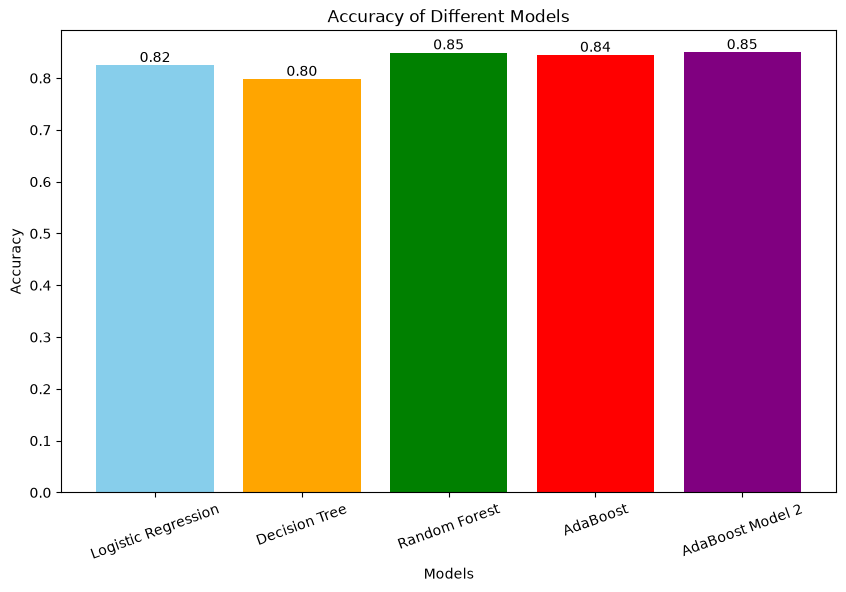

In [83]:
# VISULIZATING COMPARISON OF ALL MODELS ACCOURACY SCORE
colors = ["skyblue", "orange", "green", "red", "purple"]

plt.figure(figsize=(10, 6))

bars = plt.bar(model_names, All_MODEL_ACCURACY, color=colors)

plt.bar_label(bars, fmt="%.2f")

plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Accuracy of Different Models")

plt.show()

In [88]:
from sklearn.metrics import classification_report,confusion_matrix
# Classification report for Random Forest

print(classification_report(y_test, ada_model2_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      3389
           1       0.78      0.57      0.66      1168

    accuracy                           0.85      4557
   macro avg       0.82      0.76      0.78      4557
weighted avg       0.84      0.85      0.84      4557



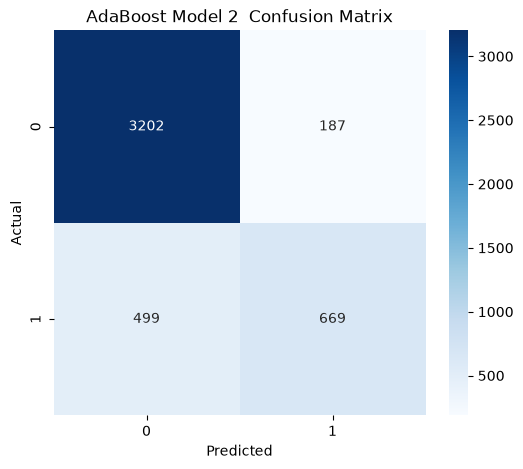

In [90]:
# Create confusion matrix

cm = confusion_matrix(y_test, ada_model2_pred )

# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("AdaBoost Model 2  Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [91]:
# Print accuracy of all models

print("Logistic Regression :", log_acc)
print("Decision Tree       :", dt_acc)
print("Random Forest       :", rf_acc)
print("AdaBoost             :", ada_acc)
print("AdaBoost Model 2     :", ada_model2_acc)

Logistic Regression : 0.8246653500109721
Decision Tree       : 0.7978933508887426
Random Forest       : 0.8490234803598858
AdaBoost             : 0.8444151854290103
AdaBoost Model 2     : 0.8494623655913979


In [ ]:
# Conclusion

'''In this project, I built a classification model to predict whether an individual's annual income is <=50K or >50K.

The project included:

- Exploratory Data Analysis
- Duplicate removal
- Missing value handling
- Outlier analysis
- Categorical feature encoding
- Train-test splitting
- Feature scaling for Logistic Regression
- Training multiple classification models
- Model accuracy comparison
- Classification report
- Confusion matrix

Five models were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. AdaBoost
5. AdaBoost with 100 estimators

Based on the test results, the ensemble models performed better than Logistic Regression and Decision Tree on this dataset.

The final model was selected based on its test performance and evaluation metrics.
AdaBoost Model 2 achieved the highest test accuracy of 84.95% among the evaluated models and was selected as the final model for detailed evaluation.'''

"In this project, I built a classification model to predict whether an individual's annual income is <=50K or >50K.\n\nThe project included:\n\n- Exploratory Data Analysis\n- Duplicate removal\n- Missing value handling\n- Outlier analysis\n- Categorical feature encoding\n- Train-test splitting\n- Feature scaling for Logistic Regression\n- Training multiple classification models\n- Model accuracy comparison\n- Classification report\n- Confusion matrix\n\nFive models were evaluated:\n\n1. Logistic Regression\n2. Decision Tree\n3. Random Forest\n4. AdaBoost\n5. AdaBoost with 100 estimators\n\nBased on the test results, the ensemble models performed better than Logistic Regression and Decision Tree on this dataset.\n\nThe final model was selected based on its test performance and evaluation metrics."